In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from collections import Counter


class KNN:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        return np.array([self._predict(x) for x in X])

    def _predict(self, x):
        distances = [np.sqrt(np.sum((x - x_train)**2)) for x_train in self.X_train]
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_indices]
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

def get_data(dataset_func):
    data = dataset_func()
    X, y = data.data, data.target
    X = StandardScaler().fit_transform(X)
    return X, y

X_wine, y_wine = get_data(load_wine)

In [16]:
print(X_wine)

[[ 1.51861254 -0.5622498   0.23205254 ...  0.36217728  1.84791957
   1.01300893]
 [ 0.24628963 -0.49941338 -0.82799632 ...  0.40605066  1.1134493
   0.96524152]
 [ 0.19687903  0.02123125  1.10933436 ...  0.31830389  0.78858745
   1.39514818]
 ...
 [ 0.33275817  1.74474449 -0.38935541 ... -1.61212515 -1.48544548
   0.28057537]
 [ 0.20923168  0.22769377  0.01273209 ... -1.56825176 -1.40069891
   0.29649784]
 [ 1.39508604  1.58316512  1.36520822 ... -1.52437837 -1.42894777
  -0.59516041]]


In [17]:

indices = np.arange(X_wine.shape[0])
np.random.seed(42)
np.random.shuffle(indices)
X_wine, y_wine = X_wine[indices], y_wine[indices]


k_neighbors = 5 # фиксируем k для соседей
n_folds = 5
fold_size = len(X_wine) // n_folds
accuracies = []


for i in range(n_folds):
    start, end = i * fold_size, (i + 1) * fold_size

    X_val, y_val = X_wine[start:end], y_wine[start:end]
    X_train = np.concatenate([X_wine[:start], X_wine[end:]], axis=0)
    y_train = np.concatenate([y_wine[:start], y_wine[end:]], axis=0)

    knn = KNN(k=k_neighbors)
    knn.fit(X_train, y_train)
    preds = knn.predict(X_val)

    acc = np.mean(preds == y_val)
    accuracies.append(acc)
    print(f"Фолд {i+1}: Точность = {acc:.4f} \t|\t {preds} ")

Фолд 1: Точность = 0.9429 	|	 [0 0 2 0 1 0 1 2 1 2 0 2 0 2 0 1 1 1 0 1 0 1 1 2 2 2 1 0 1 0 0 1 2 0 0] 
Фолд 2: Точность = 1.0000 	|	 [0 2 2 1 2 0 1 1 1 2 0 1 1 2 0 1 0 0 2 2 1 1 0 1 0 2 1 1 2 0 0 0 2 0 0] 
Фолд 3: Точность = 0.9429 	|	 [0 2 1 0 2 1 0 2 1 1 0 1 0 0 1 0 0 2 1 1 1 0 1 1 1 2 2 0 1 2 2 1 0 0 1] 
Фолд 4: Точность = 0.9429 	|	 [2 2 1 2 1 1 1 0 0 2 0 2 0 0 1 1 0 0 0 1 0 2 2 1 1 2 2 2 1 0 0 1 2 2 0] 
Фолд 5: Точность = 0.9714 	|	 [1 2 2 2 2 1 0 1 0 2 0 0 1 0 0 2 1 0 2 2 0 0 2 2 2 1 1 1 1 1 1 2 0 0 1] 


In [18]:
data = load_wine()
X = StandardScaler().fit_transform(data.data)
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

k_values = range(1, 31)
errors = []

for k in k_values:
    knn = KNN(k=k)
    knn.fit(X_train, y_train)
    preds = knn.predict(X_test)
    error = np.mean(preds != y_test) # Доля неверных предсказаний
    errors.append(error)

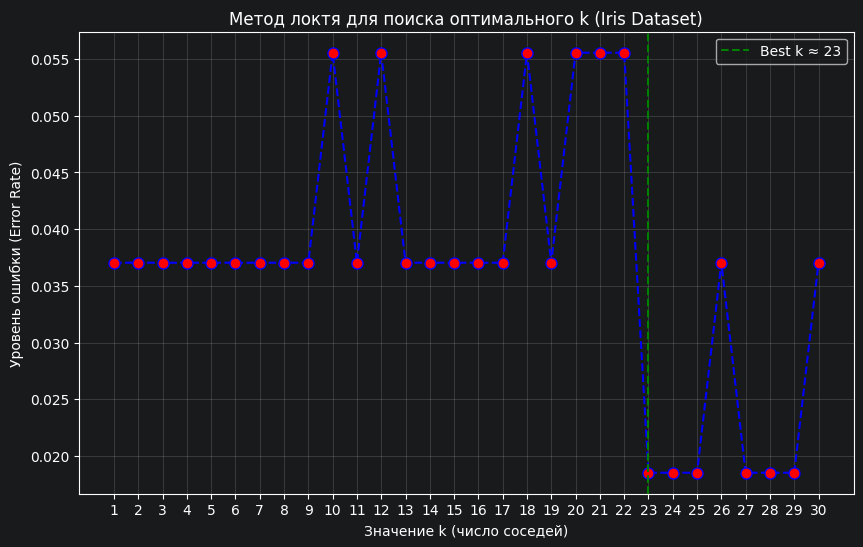

In [19]:
# Визуализация метода локтя
plt.figure(figsize=(10, 6))
plt.plot(k_values, errors, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=8)

best_k = k_values[np.argmin(errors)]
plt.axvline(x=best_k, color='green', linestyle='--', label=f'Best k ≈ {best_k}')

plt.title('Метод локтя для поиска оптимального k (Iris Dataset)')
plt.xlabel('Значение k (число соседей)')
plt.ylabel('Уровень ошибки (Error Rate)')
plt.xticks(k_values)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



In [30]:
wine = load_wine()
X_subset = wine.data[:, :2]  # <--- Ключевое изменение: берем только 2 колонки
y = wine.target

scaler = StandardScaler()
X = scaler.fit_transform(X_subset)

# k = 10 # bad One
k = best_k # good One
knn = KNN(k=k)
knn.fit(X, y)

# Создание сетки для отрисовки границ
h = .05  # шаг сетки
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Предсказание для каждой точки сетки
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)


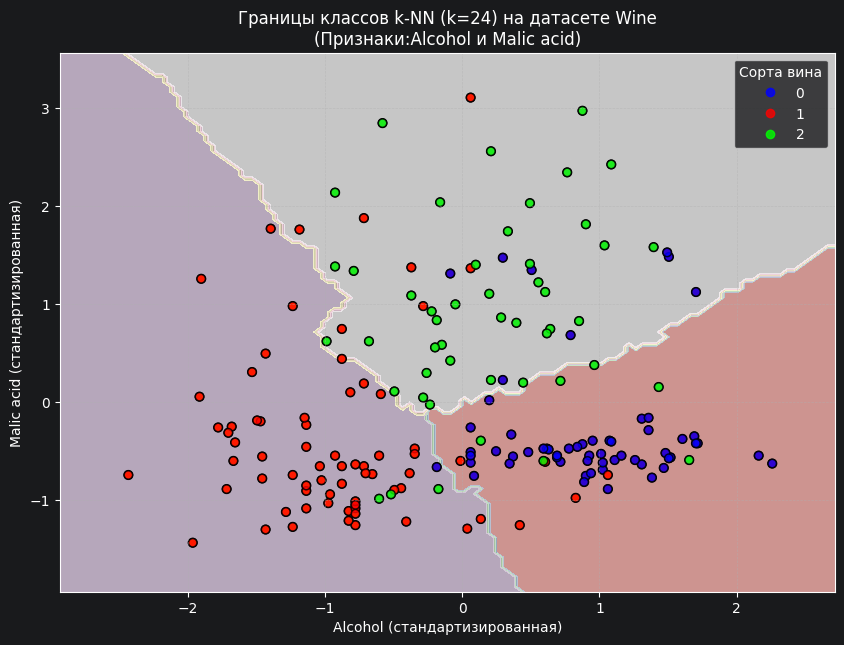

In [29]:

# Визуализация
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, cmap=plt.cm.Pastel1, alpha=0.8) # Заливка областей
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Set1, edgecolor='k', s=40) # Точки данных

scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='brg', edgecolors='black', alpha=0.8)
plt.legend(*scatter.legend_elements(), title="Сорта вина")

plt.title(f"Границы классов k-NN (k={k}) на датасете Wine\n(Признаки:Alcohol и Malic acid)")
plt.xlabel("Alcohol (стандартизированная)")
plt.ylabel("Malic acid (стандартизированная)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

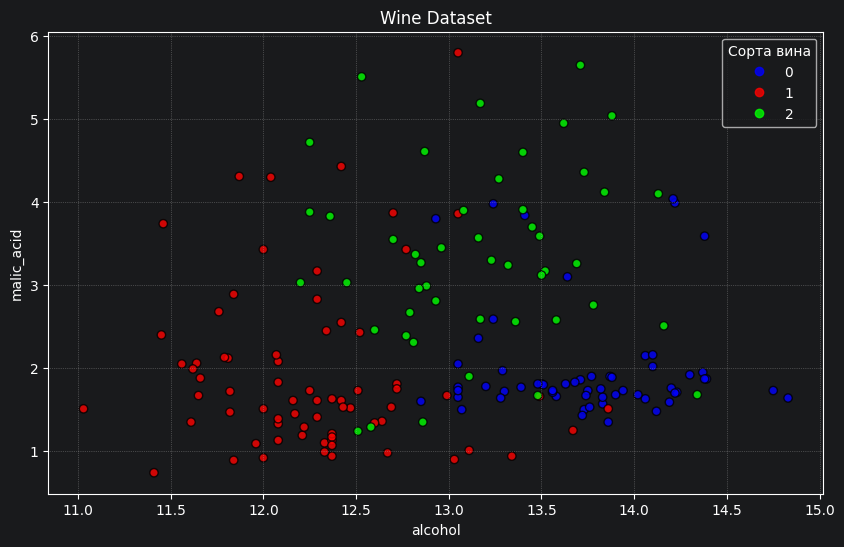

In [24]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine


wine = load_wine()
X = wine.data
y = wine.target


plt.figure(figsize=(10, 6))


scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='brg', edgecolors='black', alpha=0.8)

plt.xlabel(wine.feature_names[0])
plt.ylabel(wine.feature_names[1])
plt.title('Визуализация Wine Dataset (первые два признака)')

plt.legend(*scatter.legend_elements(), title="Сорта вина")

plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
